## Multi-Agent — Supervisor Delegates to Workers in LangGraph


In [41]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")


# --- 1. TOOLS ---
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    return f"Web results for '{query}': [top 3 articles found]"


@tool
def write_code(task: str) -> str:
    """Write Python code for a given task."""
    return f"```python\n# Code for: {task}\nprint('done')\n```"


@tool
def analyze_data(description: str) -> str:
    """Analyze data and return key insights."""
    return f"Analysis of '{description}': 3 trends found, 1 anomaly."

In [42]:
from langchain_core.messages import BaseMessage
from typing import TypedDict, Annotated
import operator


# --- 2. STATE ---
class State(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]
    next_agent: str

In [ ]:
from langgraph.prebuilt import ToolNode  # ✅
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage


# --- 3. WORKER FACTORY ---
def make_worker(prompt: str, worker_tools: list):
    wllm = ChatOpenAI(model="gpt-4o-mini").bind_tools(worker_tools)
    tnode = ToolNode(worker_tools)  # ✅

    def worker(state: State) -> dict:
        print(f"[worker] {prompt}...")
        resp = wllm.invoke([SystemMessage(prompt)] + state["messages"])
        if resp.tool_calls:
            tool_resp = tnode.invoke({"messages": [resp]})
            return {"messages": [resp] + tool_resp["messages"]}
        return {"messages": [resp]}

    return worker


researcher = make_worker("You are a web research specialist. Use search_web.", [search_web])
coder = make_worker("You are a coding specialist. Use write_code.", [write_code])
analyst = make_worker("You are a data analyst. Use analyze_data.", [analyze_data])

In [43]:
from langgraph.graph import END
from typing import Literal

# --- 4. SUPERVISOR ---
VALID_AGENTS = {"researcher", "coder", "analyst", "finish"}


def supervisor_node(state: State) -> dict:
    sys = SystemMessage(
        "You are a supervisor managing three agents: researcher, coder, analyst.\n"
        "Based on the conversation, decide who should act next.\n"
        "Reply with ONLY one word — no punctuation, no explanation:\n"
        "  researcher  →  to search for information\n"
        "  coder       →  to write code\n"
        "  analyst     →  to analyze data\n"
        "  FINISH      →  when the task is complete\n"
        "Your entire response must be a single word from the list above."
    )
    resp = llm.invoke([sys] + state["messages"])

    # Parse: take only the first word and lowercase it
    raw = resp.content.strip().lower()
    decision = raw.split()[0].strip("*_.,!") if raw else "finish"

    # Fallback: if still not a valid option, default to FINISH
    if decision not in VALID_AGENTS:
        print(f"[supervisor] ⚠️  Unexpected response: {raw!r} → defaulting to FINISH")
        decision = "finish"

    print(f"[supervisor] → {decision}")
    return {"next_agent": decision, "messages": [resp]}


def route(state: State) -> Literal["researcher", "coder", "analyst", "__end__"]:
    return END if state["next_agent"] == "finish" else state["next_agent"]

In [44]:
from langgraph.graph import StateGraph, START, END

# --- 5. GRAPH ---
builder = StateGraph(State)
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", researcher)
builder.add_node("coder", coder)
builder.add_node("analyst", analyst)
builder.add_edge(START, "supervisor")
builder.add_conditional_edges(
    "supervisor",
    route,
    {
        "researcher": "researcher",
        "coder": "coder",
        "analyst": "analyst",
        END: END,
    },
)
for w in ["researcher", "coder", "analyst"]:
    builder.add_edge(w, "supervisor")
graph = builder.compile()

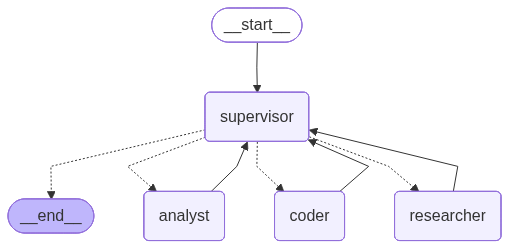

In [45]:
# --- 6. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
from langchain_core.messages import HumanMessage
from pprint import pprint

# --- 7. RUN ---
result = graph.invoke(
    {
        "messages": [HumanMessage("Search for LangGraph info, then write code to install it.")],
        "next_agent": "",
    }
)
print("\n✅")
pprint(result["messages"])

[supervisor] → researcher
[worker] You are a web research specialist. Use search_web....
[supervisor] → coder
[worker] You are a coding specialist. Use write_code....
[supervisor] → finish

✅
[HumanMessage(content='Search for LangGraph info, then write code to install it.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='researcher', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 114, 'total_tokens': 116, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_9a79c9e034', 'id': 'chatcmpl-DZjFS3fHNk90m4p31p6HHR8mrs9Xj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd5c2-7950-7e72-a32f-1e0be62335f8-0', tool_calls=[], invalid_